In [117]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode

In [118]:
from langgraph.graph import MessagesState
class MessagesState(MessagesState):
  pass

In [ ]:

pip install -U langchain-google-genai

In [121]:
## For chat bot we need Interactive Message so first wen need LLM
import os
from google.colab import userdata
os.environ['GOOGLE_API_KEY']=userdata.get('GEMINI5')

In [122]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm=ChatGoogleGenerativeAI(
    model="gemini-2.5-flash")

In [ ]:
pip install -U duckduckgo-search langchain-community

In [78]:
pip install -U ddgs

In [79]:
# importing the tool Information
from langchain_core.tools import tool
from langgraph.prebuilt import tool_node, tools_condition


In [80]:
from langchain_community.tools import DuckDuckGoSearchResults
search = DuckDuckGoSearchResults()

In [123]:
# importing DUCk DUCK Search toola
@tool
def SearchEngine(query: str):
  ''' You are FOMO Guardian.

Always call a tool first whenever
latest information is needed.

Use tool output as the primary source.

Use your own knowledge only
to explain the tool result.

Never hallucinate current information.'''
  return search.invoke(query)

In [84]:
pip install langgraph-checkpoint-sqlite

In [124]:
# Now add the Memory]
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver
checkpointer=sqlite3.connect('FOMO.db', check_same_thread=False) # SO we can generate responses with diffrent threads
Memory=SqliteSaver(checkpointer)


##Agents

Weather Tool

In [125]:
@tool
def WeatherTool(city: str):
    """
    Returns the latest weather information.
    """
    return search.run(f"Current weather in {city}")

Translation Tool

In [126]:
@tool
def TranslateTool(text: str, language: str):
    """
    Translate text into the given language.
    """
    prompt = f"""
    Translate the following text into {language}.

    Text:
    {text}
    """

    return llm.invoke(prompt).content

In [127]:
@tool
def CategoryNews(category: str):
    """
    Search latest news by category.

    Example:
    AI
    Visa
    Jobs
    Scholarships
    Business
    """
    return search.run(f"Latest {category} news")

In [128]:
@tool
def SummarizeTool(text: str):
    """
    Summarize the given text.
    """

    prompt = f"""
    Summarize the following information.

    {text}
    """

    return llm.invoke(prompt).content

In [129]:
@tool
def SentimentTool(text: str):
    """
    Detect whether the text is
    Positive,
    Neutral or
    Negative.
    """

    prompt = f"""
    Classify this text as

    Positive
    Neutral
    Negative

    Text:

    {text}
    """

    return llm.invoke(prompt).content

In [130]:
@tool
def FOMOPriority(news: str):
    """
    Classify news into

    Critical
    Important
    Can Wait
    Ignore
    """

    prompt = f"""
    You are a FOMO Assistant.

    Read the news.

    Classify it into

    Critical
    Important
    Can Wait
    Ignore

    Also explain why.

    News:

    {news}
    """

    return llm.invoke(prompt).content

In [131]:
@tool
def OpportunityFinder(news: str):
    """
    Extract opportunities from news.
    """

    prompt = f"""
    Find

    Scholarships

    Jobs

    Internship

    Visa Updates

    Deadlines

    Government Announcements

    from

    {news}
    """

    return llm.invoke(prompt).content

In [132]:
@tool
def ReminderTool(text: str):
    """
    Extract reminder dates from text.
    """

    prompt = f"""
    Find all important deadlines.

    {text}
    """

    return llm.invoke(prompt).content

In [133]:
tools = [
    SearchEngine,
    WeatherTool,
    TranslateTool,
    CategoryNews,
    SummarizeTool,
    SentimentTool,
    FOMOPriority,
    OpportunityFinder,
    ReminderTool
]

llm_with_tools = llm.bind_tools(tools)

tool_node = ToolNode(tools)

In [135]:
def ChatAgent(state:MessagesState ):

    prompt = f"""
User Query:

{state['query']}

Search Results:

{state['raw_results']}

Answer the user using only these search results.
"""

    response = llm_with_tools.invoke(prompt)

    return {
        "query": state["query"],
        "raw_results": state["raw_results"],
        "response": response.content
    }

In [136]:
# Creating graph

from langgraph.graph import StateGraph, START, END


In [137]:

graph_var = StateGraph(MessagesState)

In [138]:
graph_var.add_node(
    "ChatNode",
    ChatAgent
)

graph_var.add_node(
    "tools",
    ToolNode(tools)
)


In [139]:
graph_var.add_edge(
    START,
    "ChatNode"
)

# ChatNode -> Tool OR END
graph_var.add_conditional_edges(
    "ChatNode",
    tools_condition,
    {
        "tools": "tools",
        "__end__": END
    }
)

# Tool -> ChatNode
graph_var.add_edge(
    "tools",
    "ChatNode"
)

In [140]:
graph = graph_var.compile(checkpointer=Memory)

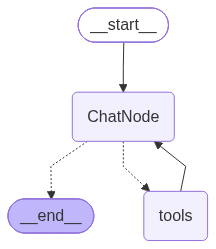

In [141]:
graph

In [142]:
from langchain_core.messages import HumanMessage, SystemMessage

In [143]:
system_prompt = """
You are FOMO Guardian AI.

Rules:

1. ALWAYS use tools whenever the user's question depends on:
   - Latest news
   - Current events
   - Jobs
   - Scholarships
   - Visa updates
   - Government announcements
   - Weather
   - Market trends

2. Never guess when a tool can provide fresher information.

3. Give highest priority to tool outputs.

4. Use your own knowledge only to:
   - explain,
   - compare,
   - simplify,
   - provide context.

5. If tool output and your prior knowledge differ,
always trust the tool output.

6. Clearly mention when information comes from current search results.

You are FOMO Guardian.

Always call a tool first whenever
latest information is needed.

Use tool output as the primary source.

Use your own knowledge only
to explain the tool result.

Never hallucinate current information.

"""

In [145]:
res=graph.invoke({'messages':[SystemMessage(content=system_prompt),
                          HumanMessage(content='hello? ')]},
                {'configurable': {'thread_id': 'political'}}
                           )
for every in res['messages']:
  every.pretty_print()

KeyError: 'query'